<a href="https://colab.research.google.com/github/Lambertlan123/stock-prediction/blob/main/NVIDIA_Corp_Stock.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import yfinance as yf

# Download historical data for NVIDIA Corp
stock_data = yf.download('NVDA', start='2020-01-01', end='2026-04-10')

# Save it to a CSV file
stock_data.to_csv('NVDA_data.csv')

/tmp/ipykernel_2707/1861427216.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download('NVDA', start='2020-01-01', end='2026-04-10')
[*********************100%***********************]  1 of 1 completed


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Step 1: Load the historical stock data
data = pd.read_csv('NVDA_data.csv')

In [7]:
data# Check the first few rows

,Price,Close,High,Low,Open,Volume
0,Ticker,NVDA,NVDA,NVDA,NVDA,NVDA
1,Date,NaN,NaN,NaN,NaN,NaN
2,2020-01-02,5.970753192901611,5.970753192901611,5.8913625714305295,5.9418839191567505,237536000
3,2020-01-03,5.875187397003174,5.918989509206405,5.826158936868676,5.851046511408945,205384000
4,2020-01-06,5.899824619293213,5.905050966215078,5.75572649719555,5.781858231804876,262636000
...,...,...,...,...,...,...
1572,2026-04-02,177.38999938964844,177.49000549316406,171.3699951171875,172.17999267578125,143143200
1573,2026-04-06,177.63999938964844,177.7899932861328,175.75999450683594,177.16000366210938,107564300
1574,2026-04-07,178.10000610351562,178.22999572753906,173.66000366210938,175.72999572753906,132534900
1575,2026-04-08,182.0800018310547,185.25999450683594,180.3000030517578,184.5,147732700


In [8]:
data = data.iloc[2:].reset_index(drop=True)  # Drop first two rows, reset index
data

,Price,Close,High,Low,Open,Volume
0,2020-01-02,5.970753192901611,5.970753192901611,5.8913625714305295,5.9418839191567505,237536000
1,2020-01-03,5.875187397003174,5.918989509206405,5.826158936868676,5.851046511408945,205384000
2,2020-01-06,5.899824619293213,5.905050966215078,5.75572649719555,5.781858231804876,262636000
3,2020-01-07,5.971251487731934,6.017044442487873,5.883149809298522,5.928196075296092,314856000
4,2020-01-08,5.982451438903809,6.023764739731018,5.926952474390596,5.967021135605146,277108000
...,...,...,...,...,...,...
1570,2026-04-02,177.38999938964844,177.49000549316406,171.3699951171875,172.17999267578125,143143200
1571,2026-04-06,177.63999938964844,177.7899932861328,175.75999450683594,177.16000366210938,107564300
1572,2026-04-07,178.10000610351562,178.22999572753906,173.66000366210938,175.72999572753906,132534900
1573,2026-04-08,182.0800018310547,185.25999450683594,180.3000030517578,184.5,147732700


In [9]:
data.columns

Index(['Price', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

In [10]:
# Rename the 'Price' column to 'Date'
data.rename(columns={'Price': 'Date'}, inplace=True)

# Convert 'Date' to datetime format
data['Date'] = pd.to_datetime(data['Date'], errors='coerce')

# Check the columns to ensure nothing was dropped
print(data.columns)

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')


In [11]:
data

,Date,Close,High,Low,Open,Volume
0,2020-01-02,5.970753192901611,5.970753192901611,5.8913625714305295,5.9418839191567505,237536000
1,2020-01-03,5.875187397003174,5.918989509206405,5.826158936868676,5.851046511408945,205384000
2,2020-01-06,5.899824619293213,5.905050966215078,5.75572649719555,5.781858231804876,262636000
3,2020-01-07,5.971251487731934,6.017044442487873,5.883149809298522,5.928196075296092,314856000
4,2020-01-08,5.982451438903809,6.023764739731018,5.926952474390596,5.967021135605146,277108000
...,...,...,...,...,...,...
1570,2026-04-02,177.38999938964844,177.49000549316406,171.3699951171875,172.17999267578125,143143200
1571,2026-04-06,177.63999938964844,177.7899932861328,175.75999450683594,177.16000366210938,107564300
1572,2026-04-07,178.10000610351562,178.22999572753906,173.66000366210938,175.72999572753906,132534900
1573,2026-04-08,182.0800018310547,185.25999450683594,180.3000030517578,184.5,147732700


In [12]:
# Keep only the 'Close' price column
data['Close'] = pd.to_numeric(data['Close'], errors='coerce')
prices = data['Close'].values
prices = prices.reshape(-1, 1)

# Step 2: Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(prices)

# Define training data length (80% of the data for training)
train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

# Step 3: Create the training datasets
def create_dataset(data, time_step=60):
    X, y = [], []
    for i in range(time_step, len(data)):
        X.append(data[i-time_step:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

time_step = 60  # Use 60 days of previous data to predict the next day
X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

In [13]:
# Reshape input to be [samples, time steps, features] for LSTM
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Step 4: Build the LSTM model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))  # Dropout to prevent overfitting
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=25))
model.add(Dense(units=1))  # Output layer

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Step 5: Train the model
model.fit(X_train, y_train, epochs=10, batch_size=64)

# Step 6: Make predictions
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)  # Reverse scaling

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - loss: 0.0172
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - loss: 0.0025
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - loss: 0.0012
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - loss: 0.0011
Epoch 5/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.0010
Epoch 6/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 0.0010    
Epoch 7/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - loss: 0.0010    
Epoch 8/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - loss: 8.5326e-04
Epoch 9/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - loss: 8.4967e-04
Epoch 10/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 7.3189e-04
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step


In [14]:
print(data.columns)

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')


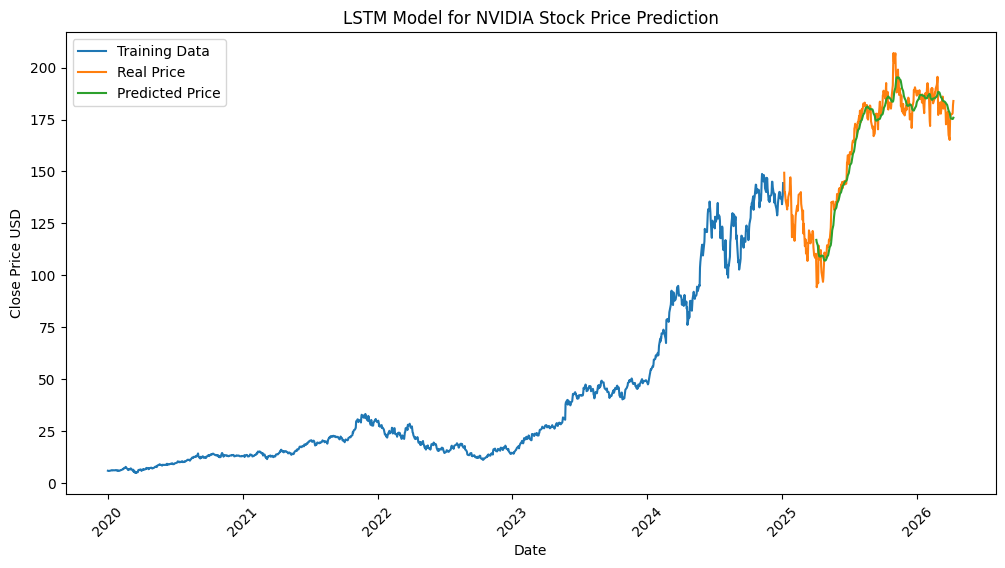

In [15]:
####
# Convert 'Date' column to DateTime if it's not already
data['Date'] = pd.to_datetime(data['Date'])

# Set the 'Date' as the index of the DataFrame for easier plotting
data.set_index('Date', inplace=True)

# Adjust the train and valid DataFrames to include Date as the index
train = data[:train_size]
valid = data[train_size:]
valid = valid.copy()
valid.loc[:, 'Predictions'] = np.nan
valid.loc[valid.index[-len(predictions):], 'Predictions'] = predictions.reshape(-1)

# Plotting the results with actual dates on the x-axis
plt.figure(figsize=(12,6))
plt.title('LSTM Model for NVIDIA Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Close Price USD')
plt.plot(train['Close'], label='Training Data')
plt.plot(valid['Close'], label='Real Price')
plt.plot(valid['Predictions'], label='Predicted Price')
plt.legend(loc='upper left')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()

In [16]:
# Number of future days you want to predict
future_days = 20  # You can change this to however many days you want

# Get the last 60 days of data from the test set
last_sequence = scaled_data[-time_step:]  # Last 60 days (already scaled)

# Create an empty list to store future predictions
future_predictions = []

# Predict future prices
for _ in range(future_days):
    # Reshape the last sequence for prediction (LSTM expects input shape of (samples, time steps, features))
    last_sequence_reshaped = last_sequence.reshape((1, time_step, 1))

    # Predict the next day price
    predicted_price = model.predict(last_sequence_reshaped)

    # Append the prediction to future_predictions
    future_predictions.append(predicted_price[0, 0])

    # Update the last_sequence by appending the predicted price and removing the oldest data point
    last_sequence = np.append(last_sequence, predicted_price)[1:]  # Maintain 60 days sliding window

# Inverse transform the predicted future prices to get them back to the original scale
future_predictions = scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1))

# Plotting future predictions
import matplotlib.dates as mdates

# Extend the current valid set with future dates
future_dates = pd.date_range(data.index[-1], periods=future_days+1, freq='B')[1:]  # Business days only

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


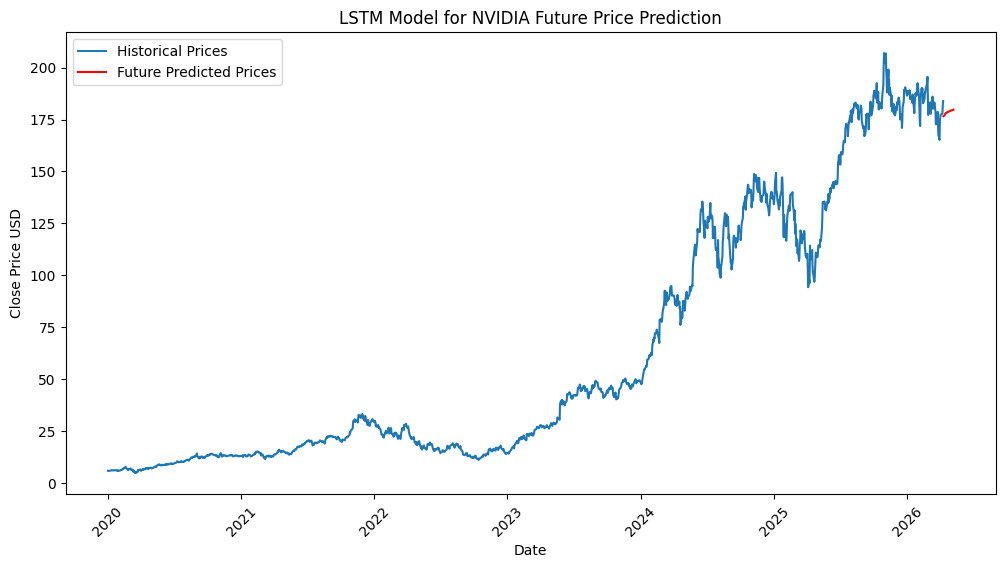

In [17]:
# Plot historical data + future predictions
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['Close'], label='Historical Prices')
plt.plot(future_dates, future_predictions, label='Future Predicted Prices', color='r')
plt.title('LSTM Model for NVIDIA Future Price Prediction')
plt.xlabel('Date')
plt.ylabel('Close Price USD')
plt.legend(loc='upper left')
plt.xticks(rotation=45)
plt.show()